# Robust Portfolio Optimization

Compare multiple benchmark portfolios and investigate whether optimal allocations remain stable across different historical windows.


> **Note**
>
> This notebook is intended for educational, research, and portfolio demonstration purposes only.
> The analyses and results are based on the available data, assumptions, and methodologies used in this notebook. They should not be interpreted as professional financial, investment, or trading advice.
>
> Past performance does not guarantee future results.

## Research Question

This project asks a practical asset allocation question:

> Can a long-only ETF portfolio achieve better risk-adjusted performance than simple benchmark allocations, while keeping the optimized weights stable across different historical windows?

The analysis focuses on three dimensions:

1. Performance: return, volatility, drawdown, Sharpe, Sortino, and Calmar ratios.
2. Allocation: how the optimized portfolio distributes weights across assets.
3. Robustness: whether the optimal weights remain stable under 3-year, 5-year, and 10-year lookback windows.

## Setup

### Project Path

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()

for parent in [cwd] + list(cwd.parents):
    if (parent / "config").exists() and (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError("Could not find project root containing both 'config' and 'src' folders.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = K:\GitDocument\GitUpload\robust-portfolio-optimization


### Figure Output Folder

This cell creates a local folder for figure export.  
<!-- The exported PNG files can be reused directly in:

- GitHub README
- `FINAL.ipynb`
- presentation / interview materials -->

In [2]:
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "01_portfolio_optimization"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "01_portfolio_optimization"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR =", FIG_DIR)
print("TABLE_DIR =", TABLE_DIR)

FIG_DIR = K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\figures\01_portfolio_optimization
TABLE_DIR = K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\tables\01_portfolio_optimization


### Import Modules

In [3]:
from IPython.display import display, Markdown
from src.portfolio_engine_core import *

from config.settings import (
    START,
    END,
    RISK_FREE_RATE,
    SEED,
    N_PORTFOLIOS,
    TARGET_RETURN,
    DEFAULT_TICKERS,
    DEFAULT_BOUNDS,
    LOOKBACK_WINDOWS,
    CACHE_DIR,
)


In [4]:
pd.options.display.float_format = "{:.4f}".format


## Methodology

The pipeline follows the standard mean-variance optimization workflow:

1. Load historical ETF price data.
2. Convert prices into daily returns.
3. Estimate annualized expected returns and covariance matrix.
4. Generate benchmark portfolios.
5. Construct three optimized portfolios:
   - Maximum Sharpe Portfolio
   - Minimum Variance Portfolio
   - Target Return Portfolio
6. Compare portfolio performance.
7. Test robustness across different historical lookback windows.

## Run Pipeline

In [5]:
results = run_pipeline(
    tickers=DEFAULT_TICKERS,
    bounds_config=DEFAULT_BOUNDS,
    start=START,
    end=END,
    n_portfolios=N_PORTFOLIOS,
    rf=RISK_FREE_RATE,
    min_return=TARGET_RETURN,
)


Loading TW_0050 from cache: price_cache_0050_TW_2016-01-01_2026-05-31.csv
Loading US_SP500 from cache: price_cache_SPY_2016-01-01_2026-05-31.csv
Loading US_NASDAQ from cache: price_cache_QQQ_2016-01-01_2026-05-31.csv
Loading GLOBAL from cache: price_cache_VT_2016-01-01_2026-05-31.csv
Loading EM from cache: price_cache_VWO_2016-01-01_2026-05-31.csv
Loading SMALL_CAP from cache: price_cache_IJR_2016-01-01_2026-05-31.csv
Loading BOND from cache: price_cache_BND_2016-01-01_2026-05-31.csv


## Price Data Preview

In [6]:
price = results["price"]
price.tail(5)


,TW_0050,US_SP500,US_NASDAQ,GLOBAL,EM,SMALL_CAP,BOND
date,,,,,,,
2026-05-25,100.8000,743.7240,716.7523,155.0100,58.9100,136.9859,72.7545
2026-05-26,100.1000,748.6613,729.4784,156.8135,60.1585,139.1693,72.9638
2026-05-27,102.5500,748.5316,728.6493,156.5943,60.2184,139.1992,73.0336
2026-05-28,100.5000,752.6609,734.7925,157.3017,59.8289,139.2989,73.1731
2026-05-29,105.4000,754.5361,737.4995,157.5508,59.8089,138.2421,73.2130


##  Shrinkage Estimation of Expected Return and Covariance



To improve the stability of portfolio optimization, the expected return vector and covariance matrix are estimated using simple shrinkage estimators rather than relying solely on sample statistics.

The mean estimator shrinks individual expected returns toward the grand mean, following the general spirit of shrinkage estimation introduced by James and Stein (1961).

The covariance estimator shrinks the sample covariance matrix toward a diagonal target, which is conceptually related to the covariance shrinkage framework developed by Ledoit and Wolf (2004).

By reducing the impact of estimation error and noisy historical observations, shrinkage estimation tends to produce more stable portfolio weights and better out-of-sample behavior.

The resulting estimates

$$
(\hat{\mu}, \hat{\Sigma})
$$

are subsequently used to construct the Maximum Sharpe portfolio, Minimum Variance portfolio, Target Return portfolio (minimum variance subject to a target return constraint), and the efficient frontier.

### Notation

Suppose there are $n$ assets and $T$ observations.

Let

$$
R=
\begin{bmatrix}
r_{1,1} & r_{1,2} & \cdots & r_{1,T}\\
r_{2,1} & r_{2,2} & \cdots & r_{2,T}\\
\vdots & \vdots & \ddots & \vdots\\
r_{n,1} & r_{n,2} & \cdots & r_{n,T}
\end{bmatrix}
\in\mathbb{R}^{n\times T}
$$

denote the matrix of asset returns, where
$
r_{i,t}
$
represents the return of asset $i$ at time $t$.

Here,

- $n$ : number of assets;
- $T$ : number of observations;
- $R$ : return matrix;
- $r_{i,t}$ : return of asset $i$ at time $t$.



---

### Mean Estimation 


The sample annualized return vector is

$$
\hat{\mu}_{\mathrm{sample}}
=
252 \times
\begin{bmatrix}
\bar r_1\\
\bar r_2\\
\vdots\\
\bar r_n
\end{bmatrix},
$$

where

$$
\bar r_i
=
\frac1T
\sum_{t=1}^{T}
r_{i,t}
$$

is the average daily return of asset $i$, and $252$ is the number of trading date in a single year.

The grand mean is defined as

$$
\bar\mu
=
\frac1n
\sum_{i=1}^{n}
\hat\mu_{\mathrm{sample},i}.
$$

The robust estimate of expected return is obtained by shrinking the sample mean toward the grand mean:

$$
\hat\mu
=
\lambda_\mu \bar\mu
+
(1-\lambda_\mu)
\hat\mu_{\mathrm{sample}},
$$

where

$$
0\le\lambda_\mu\le1
$$

is the shrinkage intensity.

---

### Covariance Matrix Estimation

The sample covariance matrix is

$$
S
=
\mathrm{Cov}(R)
\in\mathbb{R}^{n\times n}.
$$

The diagonal covariance matrix is constructed by keeping only the variances:

$$
D
=
\operatorname{diag}
(S_{11},S_{22},\ldots,S_{nn}).
$$

The robust covariance estimator is

$$
\hat\Sigma
=
(1-\lambda_\Sigma)S
+
\lambda_\Sigma D,
$$

where

$$
0\le\lambda_\Sigma\le1
$$

is the covariance shrinkage intensity.

When

- $\lambda_\Sigma=0$, the estimator reduces to the sample covariance matrix;

- $\lambda_\Sigma=1$, all correlations are assumed to be zero.

---

In this notebook, we take $\lambda_\mu=0.5$ and $\lambda_\Sigma=0.2$. 







### Mean Estimation

The sample annualized return vector is

$$
\hat{\mu}_{\text{sample}}
=
252 \times
\begin{bmatrix}
\bar r_1 \\
\bar r_2 \\
\vdots \\
\bar r_n
\end{bmatrix},
$$

where

$$
\bar r_i
=
\frac{1}{T}
\sum_{t=1}^{T} r_{i,t}.
$$

The grand mean is defined as

$$
\bar{\mu}
=
\frac{1}{n}
\sum_{i=1}^{n}
\hat{\mu}_{\text{sample},i}.
$$

To obtain a more robust estimate, the expected return vector is shrunk toward the grand mean:

$$
\hat{\mu}
=
\lambda_{\mu}\bar{\mu}
+
(1-\lambda_{\mu})
\hat{\mu}_{\text{sample}},
$$

where

- $\lambda_{\mu}\in[0,1]$ is the shrinkage intensity,
- $\lambda_{\mu}=0$ corresponds to the sample mean,
- $\lambda_{\mu}=1$ corresponds to using only the grand mean.

In this notebook, we take  $\lambda_{\mu}= 0.5$.

---

### Covariance Matrix Estimation

The sample covariance matrix is

$$
S
=
\mathrm{Cov}(R).
$$

A diagonal covariance matrix is constructed by retaining only the variances:

$$
D
=
\mathrm{diag}
\left(
S_{11},
S_{22},
\dots,
S_{nn}
\right).
$$

The robust covariance matrix is obtained by shrinking the sample covariance matrix toward the diagonal matrix:

$$
\hat{\Sigma}
=
(1-\lambda_{\Sigma})S
+
\lambda_{\Sigma}D,
$$

where

- $\lambda_{\Sigma}\in[0,1]$ is the covariance shrinkage intensity,
- $\lambda_{\Sigma}=0$ gives the sample covariance matrix,
- $\lambda_{\Sigma}=1$ assumes assets are mutually independent.

In this notebook, we take  $\lambda_{\Sigma}= 0.2$.

---

The resulting estimates

$$
(\hat{\mu},\hat{\Sigma})
$$

are then used in portfolio optimization to construct the Maximum Sharpe portfolio, Minimum Variance portfolio, Target Return(with Minimum-Variance) portfolio,  and the efficient frontier.

The shrinkage approach improves robustness by mitigating the impact of estimation error and reducing the sensitivity of optimized weights to noisy historical data.

## Portfolio Weights

The following table summarizes the asset allocation of each portfolio.

These weights are used to construct the corresponding portfolio net asset values (NAV), which will later be evaluated using:

- annualized return,
- volatility,
- downside volatility,
- maximum drawdown,
- Sharpe Ratio,
- Sortino Ratio,
- Calmar Ratio.

The resulting portfolios will also be compared through cumulative return curves, drawdown analysis, and the efficient frontier.

In [7]:
display(results["weight_table"])


,TW_0050 Only,US_SP500 Only,US_NASDAQ Only,GLOBAL Only,EM Only,SMALL_CAP Only,Equal Weight,Equity Only Equal Weight,80/20 Stock Bond,60/40 Stock Bond,Max Sharpe,Min Variance,Target Return
TW_0050,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1429,0.1667,0.1333,0.1000,0.4678,0.3625,0.3625
US_SP500,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.1429,0.1667,0.1333,0.1000,0.2235,0.2284,0.2284
US_NASDAQ,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.1429,0.1667,0.1333,0.1000,0.1528,0.0100,0.0100
GLOBAL,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.1429,0.1667,0.1333,0.1000,0.0559,0.2127,0.2127
EM,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.1429,0.1667,0.1333,0.1000,0.0000,0.0861,0.0861
SMALL_CAP,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.1429,0.1667,0.1333,0.1000,0.0000,0.0003,0.0003
BOND,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1429,0.0000,0.2000,0.4000,0.1000,0.1000,0.1000


### Maximize Sharpe Ratio 

The Maximum Sharpe Portfolio aims to maximize risk-adjusted return.

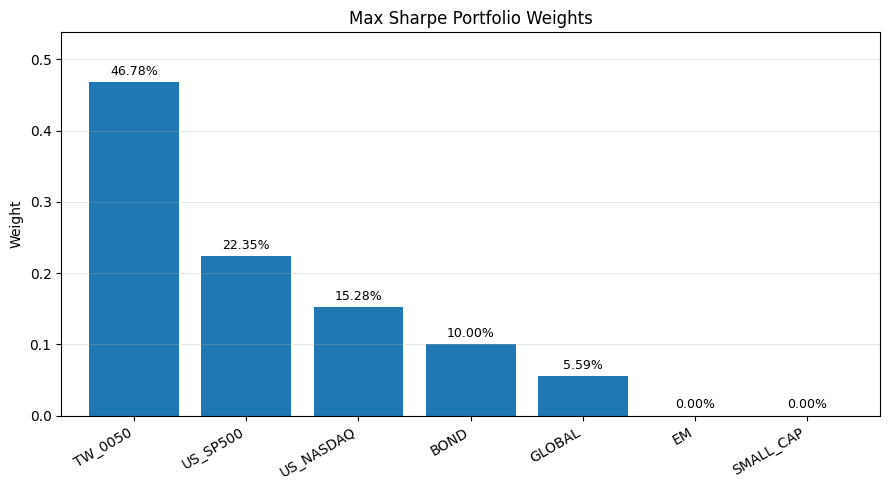

In [8]:
plot_weight_bar(
       results["portfolios"]["Max Sharpe"],
        "Max Sharpe Portfolio Weights",
        None if FIG_DIR is None else FIG_DIR / "max_sharpe_weights.png",
)



### Minimize Variance Portfolio

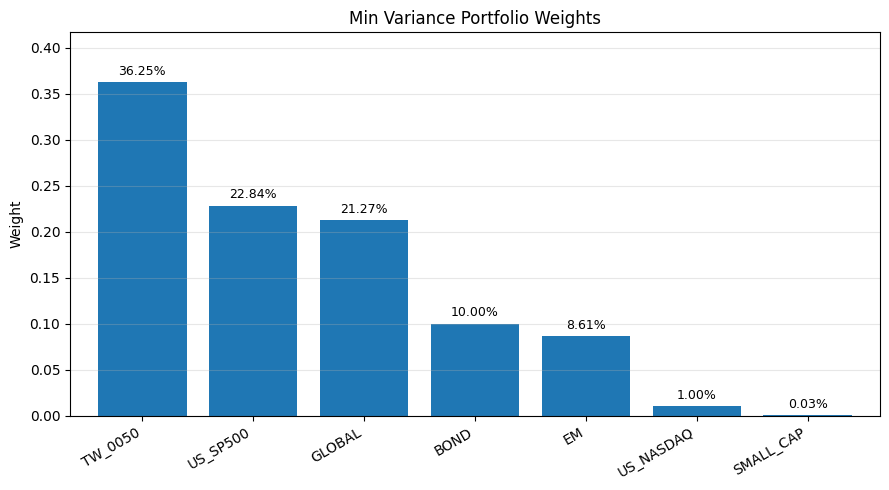

In [9]:

plot_weight_bar(
    results["portfolios"]["Min Variance"],
    "Min Variance Portfolio Weights",
    None if FIG_DIR is None else FIG_DIR / "min_variance_weights.png",
)

### Target Return (with Minimum-Variance)

In [10]:
event_summary_md = f'''
Show portfolio weights with target return {TARGET_RETURN:.2%}.
'''
display(Markdown(event_summary_md))


Show portfolio weights with target return 12.00%.


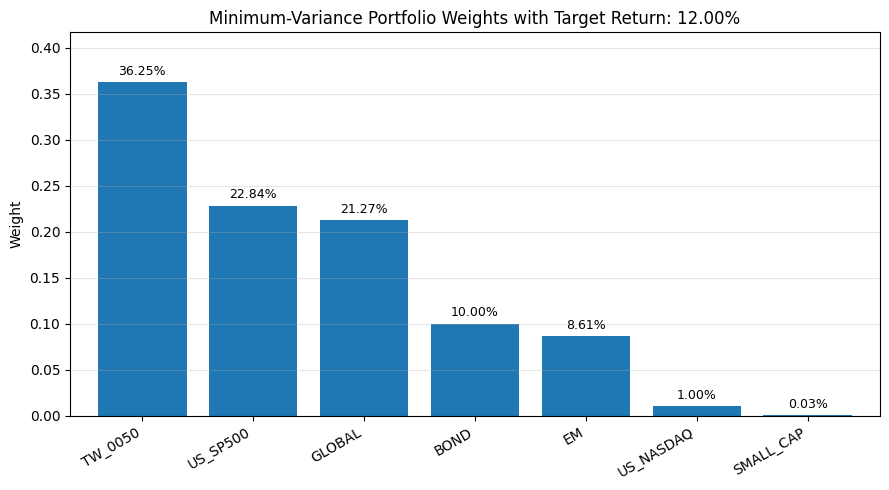

In [11]:

plot_weight_bar(
    results["portfolios"]["Target Return"],
    f"Minimum-Variance Portfolio Weights with Target Return: {TARGET_RETURN:.2%}",
    None if FIG_DIR is None else FIG_DIR / "target_return_weights.png",
)

## Performance Metrics


The following table summarizes 

- the annualized return, 
- volatility, 
- downside volatility, 
- maximum drawdown, 

and some metrics.


### Risk-adjusted Performance Metrics

<!-- The following risk-adjusted metrics are used to evaluate each portfolio. -->



#### Sharpe Ratio

Measures excess return per unit of total risk.

$$
\text{Sharpe Ratio}
=
\frac{R_p - R_f}{\sigma_p}
$$

where

- $R_p$ : annualized portfolio return
- $R_f$ : risk-free rate
- $\sigma_p$ : annualized volatility

---

#### Sortino Ratio

Measures excess return per unit of downside risk.

$$
\text{Sortino Ratio}
=
\frac{R_p - R_f}{\sigma_d}
$$

where

- $R_p$ : annualized portfolio return
- $R_f$ : risk-free rate
- $\sigma_d$ : annualized downside volatility

---

#### Calmar Ratio

Measures return relative to maximum drawdown.

$$
\text{Calmar Ratio}
=
\frac{R_p}{|\text{Max Drawdown}|}
$$

where

- $R_p$ : annualized portfolio return
- Max Drawdown : maximum observed drawdown

### Performance Table

In [12]:
display(results["metrics_table"])


,portfolio,return,volatility,downside_volatility,max_drawdown,sharpe,sortino,calmar
10,Max Sharpe,0.1842,0.1276,0.0892,-0.2712,1.3154,1.8809,0.6792
12,Target Return,0.1603,0.1239,0.0883,-0.2689,1.1612,1.6293,0.5961
11,Min Variance,0.1603,0.1239,0.0883,-0.2689,1.1612,1.6293,0.5961
0,TW_0050 Only,0.2314,0.1884,0.1271,-0.3383,1.1409,1.6917,0.6839
7,Equity Only Equal Weight,0.1598,0.1584,0.1137,-0.3180,0.9053,1.2617,0.5026
6,Equal Weight,0.1399,0.1371,0.0984,-0.2784,0.9011,1.2554,0.5027
8,80/20 Stock Bond,0.1320,0.1287,0.0924,-0.2624,0.8980,1.2508,0.5030
2,US_NASDAQ Only,0.2094,0.2185,0.1540,-0.3512,0.8830,1.2528,0.5961
9,60/40 Stock Bond,0.1042,0.1004,0.0723,-0.2204,0.8741,1.2147,0.4727
1,US_SP500 Only,0.1549,0.1758,0.1250,-0.3372,0.7880,1.1079,0.4594


## Efficient Frontier

The efficient frontier shows the risk-return trade-off among feasible portfolios under the specified allocation constraints.

The scatter points represent randomly generated candidate portfolios.  
The frontier line represents portfolios with the lowest volatility for a given target return.

Highlighted portfolios are used to compare optimized allocations against simple benchmark strategies.


Highlighted portfolios include:

- Maximum Sharpe Portfolio
- Minimum Variance Portfolio
- Target Return Portfolio
- Equal Weight Portfolio
- 80/20 Stock-Bond Portfolio
- 60/40 Stock-Bond Portfolio

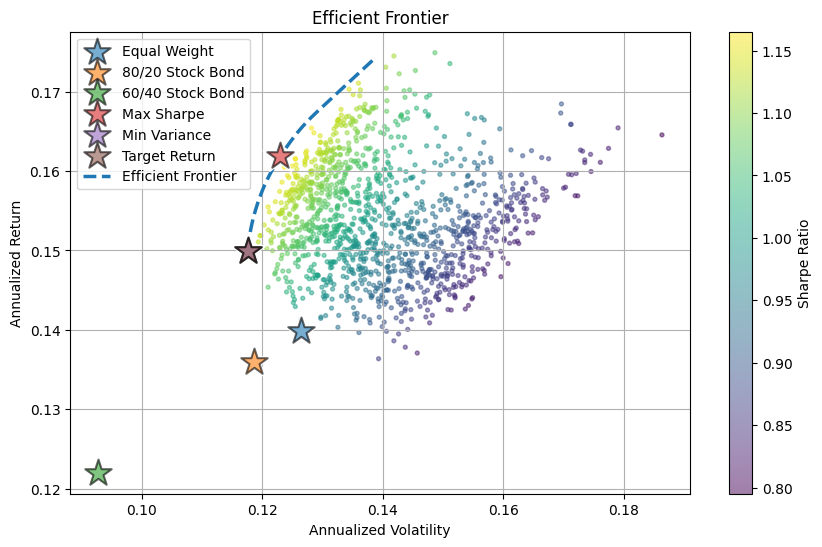

In [13]:
plot_efficient_frontier(
        results["candidate_metrics"],
        results["highlighted"],
        results["frontier"],
        None if FIG_DIR is None else FIG_DIR / "efficient_frontier.png",
        
)

In [14]:
from IPython.display import display, Markdown

# Summary table

metrics = results["metrics_table"].set_index("portfolio")

summary_df = (
    metrics.loc[
        ["Max Sharpe", "Min Variance", "Target Return"],
        ["return", "volatility", "sharpe"],
    ]
    .rename(
        columns={
            "return": "Annualized Return",
            "volatility": "Volatility",
            "sharpe": "Sharpe Ratio",
        }
    )
)

# Display table
display(
    summary_df.style.format(
        {
            "Annualized Return": "{:.2%}",
            "Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.2f}",
        }
    )
)

# Dynamic interpretation
max_sharpe = summary_df.loc["Max Sharpe"]
min_var = summary_df.loc["Min Variance"]
target = summary_df.loc["Target Return"]

md = f"""
### Efficient Frontier Interpretation

The optimized portfolios are located closer to the efficient frontier than most benchmark portfolios, indicating better risk-return efficiency under the current assumptions.

Among the highlighted portfolios, 

- the **Maximum Sharpe Portfolio** achieves the highest risk-adjusted performance, with a Sharpe ratio of **{max_sharpe['Sharpe Ratio']:.2f}**.

- The **Minimum Variance Portfolio** reduces portfolio volatility to **{min_var['Volatility']:.2%}**, while maintaining an annualized return of **{min_var['Annualized Return']:.2%}**.

- The **Target Return Portfolio** achieves an annualized return of **{target['Annualized Return']:.2%}** with a volatility of **{target['Volatility']:.2%}**, representing the lowest-risk portfolio satisfying the target return constraint.

Overall, the optimized portfolios lie closer to the estimated efficient frontier than the benchmark portfolios, indicating improved risk-return efficiency under the current model assumptions.

Nevertheless, the efficient frontier is constructed from estimated expected returns and covariance matrices. Therefore, the results should be interpreted as model-based allocation references rather than guaranteed future outcomes.
"""

display(Markdown(md))

,Annualized Return,Volatility,Sharpe Ratio
portfolio,,,
Max Sharpe,18.42%,12.76%,1.32
Min Variance,16.03%,12.39%,1.16
Target Return,16.03%,12.39%,1.16



### Efficient Frontier Interpretation

The optimized portfolios are located closer to the efficient frontier than most benchmark portfolios, indicating better risk-return efficiency under the current assumptions.

Among the highlighted portfolios, 

- the **Maximum Sharpe Portfolio** achieves the highest risk-adjusted performance, with a Sharpe ratio of **1.32**.

- The **Minimum Variance Portfolio** reduces portfolio volatility to **12.39%**, while maintaining an annualized return of **16.03%**.

- The **Target Return Portfolio** achieves an annualized return of **16.03%** with a volatility of **12.39%**, representing the lowest-risk portfolio satisfying the target return constraint.

Overall, the optimized portfolios lie closer to the estimated efficient frontier than the benchmark portfolios, indicating improved risk-return efficiency under the current model assumptions.

Nevertheless, the efficient frontier is constructed from estimated expected returns and covariance matrices. Therefore, the results should be interpreted as model-based allocation references rather than guaranteed future outcomes.


The plot shows that "Max Sharpe", "Min Variance", and "Target Return" portfolios are close to efficient frontier. Howerver, "Equal Weight", "80/20 Stock Bound", and "60/40 Stock Bound" are far from efficient frontier.

### Why does the Target Return Portfolio exceed the specified 12% target?

Although the target return was specified as **12%**, the optimized portfolio achieved an expected return close to **15%**.

This behavior is expected because the optimization problem was formulated as:

$$
\min \sigma_p
$$

subject to

$$
R_p \ge R_{target}
$$

rather than

$$
R_p = R_{target}
$$

where $R_{target}=12\%$.

In this dataset, the minimum-variance portfolio already achieved an expected return above the specified target return.

As a result, the return constraint became **non-binding**, and the optimizer selected a portfolio that was nearly identical to the minimum-variance solution.

Another important observation is that the efficient frontier does not contain portfolios with volatility lower than the minimum-variance portfolio in the region around 12% expected return.

Therefore, the optimizer cannot move toward a lower-return portfolio while simultaneously reducing portfolio risk.

Consequently, the Target Return portfolio and the Minimum Variance portfolio appear almost indistinguishable on the efficient frontier.


In [15]:
# Format table for GitHub README
summary_df_to_save = summary_df.copy()

summary_df_to_save["Annualized Return"] = (
    summary_df_to_save["Annualized Return"]
    .map(lambda x: f"{x:.2%}")
)

summary_df_to_save["Volatility"] = (
    summary_df_to_save["Volatility"]
    .map(lambda x: f"{x:.2%}")
)

summary_df_to_save["Sharpe Ratio"] = (
    summary_df_to_save["Sharpe Ratio"]
    .map(lambda x: f"{x:.2f}")
)

summary_df_to_save.index.name = "Portfolio"

# Save as markdown file
table_path = TABLE_DIR / "performance_metrics_summary.md"

summary_df_to_save.index.name = "Portfolio"
with open(table_path, "w", encoding="utf-8") as f:
    f.write(summary_df_to_save.to_markdown())



## Portfolio NAV Comparison

<!-- ## Portfolio Growth -->

This figure compares the cumulative wealth trajectories of different portfolio constructions.

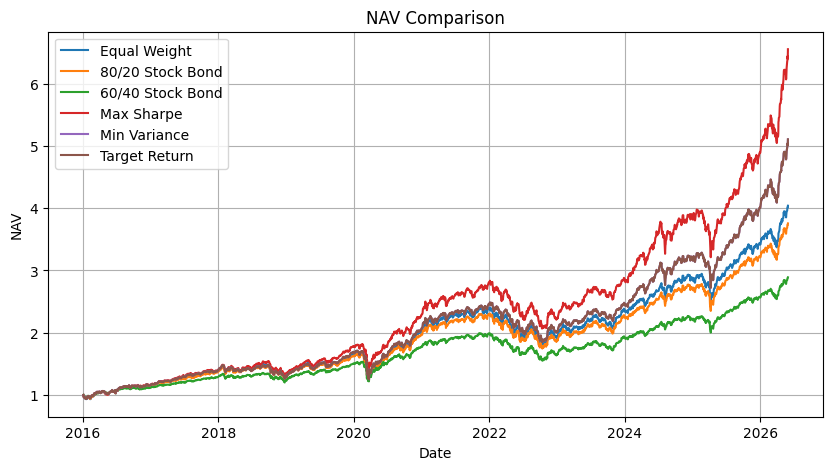

In [16]:
keys = results["portfolios"].keys()

targets = {
    "Max Sharpe", 
    "Min Variance", 
    "Equal Weight", 
    "Target Return",
    # "Equity Only Equal Weight", 
    "80/20 Stock Bond", 
    "60/40 Stock Bond"
}

assert set(targets) <= set(keys), "Plot targets not all include portfilos' tickers"

nav_and_drawdown_comparison_portfolios = {
        name: w for name, w in results["portfolios"].items() 
        if name in targets
}


plot_nav_comparison(
        results["price"],
        nav_and_drawdown_comparison_portfolios,
        None if FIG_DIR is None else FIG_DIR / "nav_comparison.png",
)



In [17]:
from IPython.display import display, Markdown

# Compute NAV summary
nav_summary = []

for name, weights in nav_and_drawdown_comparison_portfolios.items():
    nav = backtest_portfolio(results["price"], weights.values)

    nav_summary.append(
        {
            "Portfolio": name,
            "Final NAV": nav.iloc[-1],
            "Total Return": nav.iloc[-1] - 1,
        }
    )

nav_summary_df = (
    pd.DataFrame(nav_summary)
    .set_index("Portfolio")
    .sort_values("Final NAV", ascending=False)
)

display(
    nav_summary_df.style.format(
        {
            "Final NAV": "{:.2f}",
            "Total Return": "{:.2%}",
        }
    )
)

best_nav_name = nav_summary_df.index[0]
best_nav = nav_summary_df.iloc[0]["Final NAV"]
best_total_return = nav_summary_df.iloc[0]["Total Return"]

worst_nav_name = nav_summary_df.index[-1]
worst_nav = nav_summary_df.iloc[-1]["Final NAV"]

nav_md = f"""
### Portfolio NAV Comparison Interpretation

The NAV comparison shows the cumulative wealth growth of each portfolio over the full backtest period.

The **{best_nav_name}** portfolio achieves the highest ending NAV of **{best_nav:.2f}**, corresponding to a cumulative return of **{best_total_return:.2%}**.

However, a higher ending NAV does not necessarily imply superior risk-adjusted performance.

In contrast, the **{worst_nav_name}** portfolio ends with the lowest NAV of **{worst_nav:.2f}** among the selected portfolios.

The optimized portfolios generally deliver stronger cumulative growth than simple benchmark allocations, but the higher ending NAV should be interpreted together with volatility and drawdown metrics.

Therefore, this figure is useful for comparing long-term wealth accumulation, while the following drawdown and risk-adjusted performance analyses are needed to evaluate whether the additional return is achieved with acceptable risk.
"""

display(Markdown(nav_md))

,Final NAV,Total Return
Portfolio,,
Max Sharpe,6.55,555.36%
Target Return,5.11,410.55%
Min Variance,5.11,410.55%
Equal Weight,4.04,303.93%
80/20 Stock Bond,3.76,275.52%
60/40 Stock Bond,2.89,188.84%



### Portfolio NAV Comparison Interpretation

The NAV comparison shows the cumulative wealth growth of each portfolio over the full backtest period.

The **Max Sharpe** portfolio achieves the highest ending NAV of **6.55**, corresponding to a cumulative return of **555.36%**.

However, a higher ending NAV does not necessarily imply superior risk-adjusted performance.

In contrast, the **60/40 Stock Bond** portfolio ends with the lowest NAV of **2.89** among the selected portfolios.

The optimized portfolios generally deliver stronger cumulative growth than simple benchmark allocations, but the higher ending NAV should be interpreted together with volatility and drawdown metrics.

Therefore, this figure is useful for comparing long-term wealth accumulation, while the following drawdown and risk-adjusted performance analyses are needed to evaluate whether the additional return is achieved with acceptable risk.


## Drawdown Comparison


Maximum drawdown measures the largest peak-to-trough decline experienced by a portfolio.

Lower drawdowns imply better downside protection.

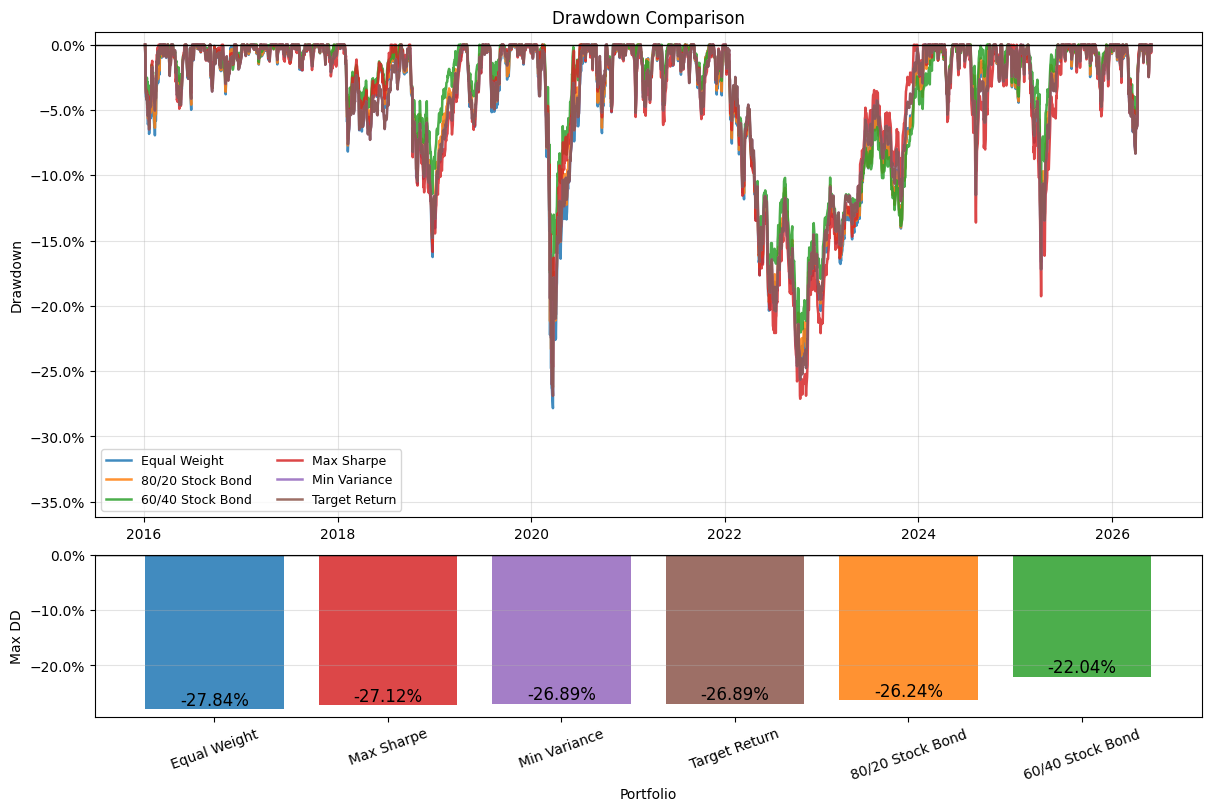

In [18]:
plot_drawdown_comparison(
        results["price"],
        nav_and_drawdown_comparison_portfolios,
        None if FIG_DIR is None else FIG_DIR / "drawdown_comparison.png",
)

In [19]:
from IPython.display import display, Markdown

selected_portfolios = list(nav_and_drawdown_comparison_portfolios.keys())

drawdown_summary_df = (
    metrics.loc[
        selected_portfolios,
        ["max_drawdown"]
    ]
    .rename(columns={"max_drawdown": "Maximum Drawdown"})
    .sort_values("Maximum Drawdown", ascending=False)
)

display(
    drawdown_summary_df.style.format(
        {"Maximum Drawdown": "{:.2%}"}
    )
)

best_dd_name = drawdown_summary_df.index[0]
best_dd = drawdown_summary_df.iloc[0, 0]

worst_dd_name = drawdown_summary_df.index[-1]
worst_dd = drawdown_summary_df.iloc[-1, 0]

md = f"""
### Drawdown Comparison Interpretation

The upper panel illustrates the drawdown trajectories of each portfolio, while the lower panel summarizes their maximum drawdowns.

Among the selected portfolios, the **{best_dd_name}** portfolio exhibits the smallest maximum drawdown of **{best_dd:.2%}**, indicating stronger downside protection during adverse market conditions.

By contrast, the **{worst_dd_name}** portfolio experiences the deepest peak-to-trough decline, reaching **{worst_dd:.2%}**.

Although cumulative return is important, drawdown analysis provides additional insights into the severity and duration of losses experienced by investors.

Consequently, drawdown measures complement volatility-based metrics and help assess the resilience of portfolio strategies under market stress.
"""

display(Markdown(md))

,Maximum Drawdown
portfolio,
60/40 Stock Bond,-22.04%
80/20 Stock Bond,-26.24%
Target Return,-26.89%
Min Variance,-26.89%
Max Sharpe,-27.12%
Equal Weight,-27.84%



### Drawdown Comparison Interpretation

The upper panel illustrates the drawdown trajectories of each portfolio, while the lower panel summarizes their maximum drawdowns.

Among the selected portfolios, the **60/40 Stock Bond** portfolio exhibits the smallest maximum drawdown of **-22.04%**, indicating stronger downside protection during adverse market conditions.

By contrast, the **Equal Weight** portfolio experiences the deepest peak-to-trough decline, reaching **-27.84%**.

Although cumulative return is important, drawdown analysis provides additional insights into the severity and duration of losses experienced by investors.

Consequently, drawdown measures complement volatility-based metrics and help assess the resilience of portfolio strategies under market stress.


## Robustness Analysis

Mean-variance optimization is sensitive to the estimation window because expected returns and covariance matrices are estimated from historical data.

To evaluate robustness, the optimization is repeated independently using 3-year, 5-year, and 10-year lookback windows.

In this project, robustness refers to the stability of portfolio characteristics and asset allocations when the historical estimation window changes.

> Robust portfolios are expected to exhibit relatively stable risk-return profiles and avoid excessive sensitivity to a particular sample period.

If optimal weights change dramatically across lookback windows, the result may be overfitted to a specific sample period.

### Maximize Sharpe Ratio

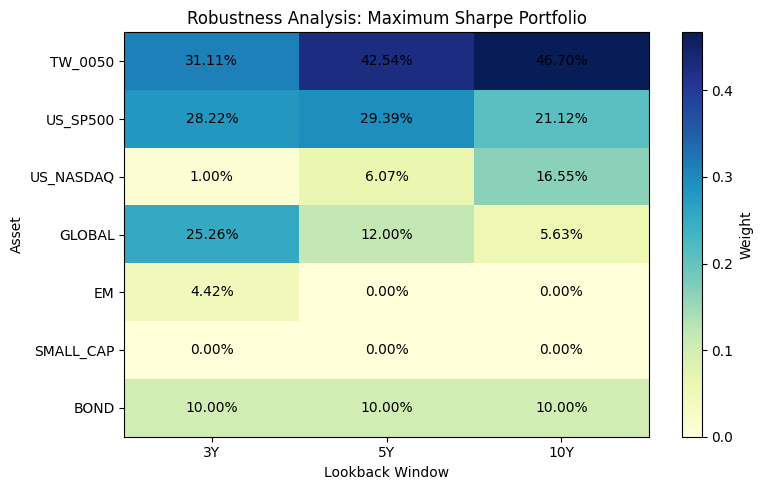

In [20]:
plot_weight_heatmap(
    results["robustness_results"]["max_sharpe_weights"],
    "Robustness Analysis: Maximum Sharpe Portfolio",
    FIG_DIR / "robustness_max_sharpe_heatmap.png",
)

### Minimize Variance

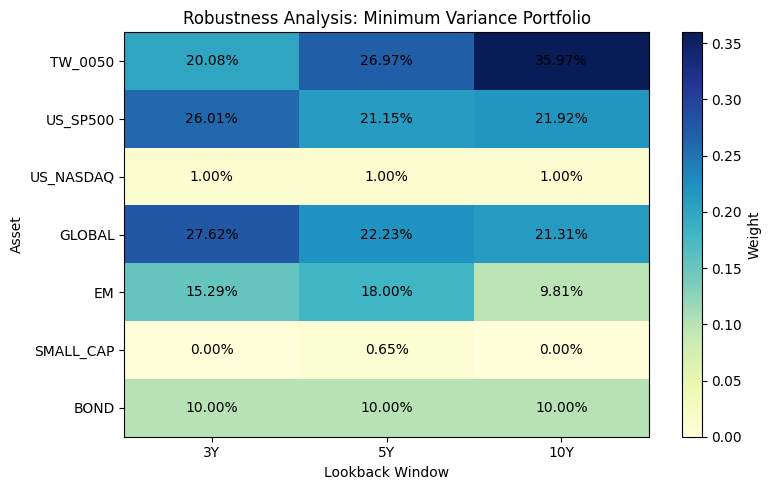

In [21]:
plot_weight_heatmap(
    results["robustness_results"]["min_variance_weights"],
    "Robustness Analysis: Minimum Variance Portfolio",
    FIG_DIR / "robustness_min_variance_heatmap.png",
)

## Robustness Analysis and Discussion

### Robust Aspects

Although the optimized weights vary across different lookback windows, several portfolio characteristics remain relatively stable.

In particular,

- annualized return,
- volatility,
- Sharpe ratio,
- maximum drawdown,

show only moderate changes across the 3-year, 5-year, and 10-year estimation windows.

These results suggest that the overall risk-return profile of the optimized portfolios is considerably more robust than the individual asset weights themselves.

The use of shrinkage estimators helps reduce estimation error and improves the stability of portfolio characteristics.


### Non-Robust Aspects

Despite the use of shrinkage estimators, the optimized portfolio weights remain sensitive to

- the historical lookback window,
- the estimated expected returns,
- and the imposed portfolio constraints.



> In particular, the Maximum Sharpe, Minimum Variance, and Target Return portfolios frequently allocate assets near their boundary constraints.
>
> This phenomenon indicates that optimized weights are considerably less stable than the resulting portfolio performance.
> 
> Such sensitivity is a well-known limitation of mean-variance optimization and has been documented extensively in the literature.
> 
> This observation suggests that portfolio performance may be substantially more robust than the corresponding asset allocations.
>
> **Therefore, robustness should not be evaluated solely by the stability of portfolio weights.**

## Conclusion

This notebook investigated whether a long-only ETF portfolio can achieve better risk-adjusted performance while maintaining stable allocations across different historical windows.

The results indicate that:

1. Mean-variance optimization can improve risk-adjusted performance relative to several benchmark portfolios.

2. Shrinkage estimators help mitigate estimation error and enhance the stability of portfolio characteristics.

3. Nevertheless, the optimized weights remain sensitive to the choice of lookback window and portfolio constraints.

4. Portfolio performance appears to be considerably more robust than the corresponding asset allocations.

Overall, the findings suggest that robustness should be evaluated not only in terms of portfolio weights, but also in terms of the resulting risk-return characteristics.

Consequently, stable performance may be more important than stable allocations when constructing practical investment portfolios.

## References of This Notebook

1. James, W., & Stein, C. (1961). *Estimation with Quadratic Loss*. Proceedings of the Fourth Berkeley Symposium on Mathematical Statistics and Probability.

   https://projecteuclid.org/euclid.bsmsp/1200512173

2. Ledoit, O., & Wolf, M. (2004). *A Well-Conditioned Estimator for Large-Dimensional Covariance Matrices*. Journal of Multivariate Analysis, 88(2), 365–411.

   https://doi.org/10.1016/S0047-259X(03)00096-4

3. Michaud, R. O. (1989). *The Markowitz Optimization Enigma: Is "Optimized" Optimal?*
   
   https://www.jstor.org/stable/4479265

4. DeMiguel, V., Garlappi, L., & Uppal, R. (2009). Optimal Versus Naive Diversification: How Inefficient is the 1/N Portfolio Strategy?
   https://doi.org/10.1093/rfs/hhm075


The implementation in this notebook is intended as a simplified and educational illustration of shrinkage-based portfolio optimization, rather than an exact reproduction of the original estimators proposed in the literature.

# Future Work

Several extensions may further improve the robustness of portfolio construction:

1. Black-Litterman model

    Incorporate equilibrium returns and investor views to obtain more stable portfolio weights.

    Reference: Black, F., & Litterman, R. (1992). Global Portfolio Optimization. https://doi.org/10.3905/jpm.1992.409394



2. Resampled Efficiency

    Average optimized portfolios over many bootstrap samples to reduce sensitivity to estimation error.

    Reference: Michaud, R. O. (1998). Efficient Asset Management. 



3. Risk Parity Portfolio

    Construct portfolios based on risk contributions rather than expected returns.



4. Regularized Portfolio Optimization

    Introduce L1 or L2 penalties to discourage extreme allocations.



5. Dynamic Asset Allocation

    Allow expected returns and covariance matrices to evolve over time.

    Examples include:

    - rolling estimation,
    - GARCH models,
    - regime-switching models,
    - Bayesian portfolio optimization.




## Save Core Figures and Tables 

In [22]:
import shutil

GITHUB_DIR = PROJECT_ROOT / "reports" / "readme" 
GITHUB_DIR.mkdir(parents=True, exist_ok=True)

GITHUB_FIG_DIR = GITHUB_DIR / "figures"
GITHUB_FIG_DIR.mkdir(parents=True, exist_ok=True)

GITHUB_TABLE_DIR = GITHUB_DIR / "tables"
GITHUB_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figures to copy to GitHub
core_figures = [
    "efficient_frontier.png", # Efficient Frontier and Highlighted Portfolios
    "nav_comparison.png", # Portfolio NAV Comparison
    "drawdown_comparison.png", # Drawdown Comparison
    "max_sharpe_weights.png", # Max Sharpe Weight Bar
    "robustness_max_sharpe_heatmap.png" # Robustness Analysis of Maximum Sharpe Portfolio
]

# Tables to copy to GitHub
table_md = [
    "performance_metrics_summary.md" # Performance Metrics Table
]

for name in (core_figures):
    src = FIG_DIR / name
    dst = GITHUB_FIG_DIR / name
    if src.exists():
        shutil.copy2(src, dst)
        print(f"Copied: {src} -> {dst}")
    else:
        print(f"Missing file: {src}")
        

for name in (table_md):
    src = TABLE_DIR / name
    dst = GITHUB_TABLE_DIR / name
    if src.exists():
        shutil.copy2(src, dst)
        print(f"Copied: {src} -> {dst}")
    else:
        print(f"Missing file: {src}")





Copied: K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\figures\01_portfolio_optimization\efficient_frontier.png -> K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\readme\figures\efficient_frontier.png
Copied: K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\figures\01_portfolio_optimization\nav_comparison.png -> K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\readme\figures\nav_comparison.png
Copied: K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\figures\01_portfolio_optimization\drawdown_comparison.png -> K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\readme\figures\drawdown_comparison.png
Copied: K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\figures\01_portfolio_optimization\max_sharpe_weights.png -> K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\readme\figures\max_sharpe_weights.png
Copied: K:\GitDocument\GitUpload\robust-portfolio-optimization\reports\figures

## Appendix: Efficient Frontier and Capital Market Line

In [23]:
cml_md = """
## Efficient Frontier with Capital Market Line

The Maximum Sharpe portfolio is also known as the **Tangency Portfolio**.

It is the portfolio where a line starting from the risk-free rate is tangent to the efficient frontier.

This tangent line is called the **Capital Market Line (CML)**.
"""

display(Markdown(cml_md))


## Efficient Frontier with Capital Market Line

The Maximum Sharpe portfolio is also known as the **Tangency Portfolio**.

It is the portfolio where a line starting from the risk-free rate is tangent to the efficient frontier.

This tangent line is called the **Capital Market Line (CML)**.


In [24]:
# Prepare data
candidate_metrics = results["candidate_metrics"]
frontier = results["frontier"]
portfolios = results["portfolios"]

rf = RISK_FREE_RATE

# Tangency Portfolio = Max Sharpe Portfolio
tangency_weights = portfolios["Max Sharpe"]

tangency_return = portfolio_return(
    tangency_weights.values,
    results["mu"].values,
)

tangency_volatility = portfolio_volatility(
    tangency_weights.values,
    results["cov"].values,
)

tangency_sharpe = portfolio_sharpe(
    tangency_weights.values,
    results["mu"].values,
    results["cov"].values,
    rf=rf,
)

# Capital Market Line
cml_x = np.linspace(
    0,
    candidate_metrics["volatility"].max() * 1.15,
    500,
)

cml_y = rf + tangency_sharpe * cml_x

cml_summary_md = f"""
### Tangency Portfolio Summary

| Metric | Value |
|:--|--:|
| Risk-Free Rate | {rf:.2%} |
| Tangency Portfolio Return | {tangency_return:.2%} |
| Tangency Portfolio Volatility | {tangency_volatility:.2%} |
| Tangency Portfolio Sharpe Ratio | {tangency_sharpe:.2f} |
"""

display(Markdown(cml_summary_md))


### Tangency Portfolio Summary

| Metric | Value |
|:--|--:|
| Risk-Free Rate | 1.64% |
| Tangency Portfolio Return | 16.18% |
| Tangency Portfolio Volatility | 12.30% |
| Tangency Portfolio Sharpe Ratio | 1.18 |


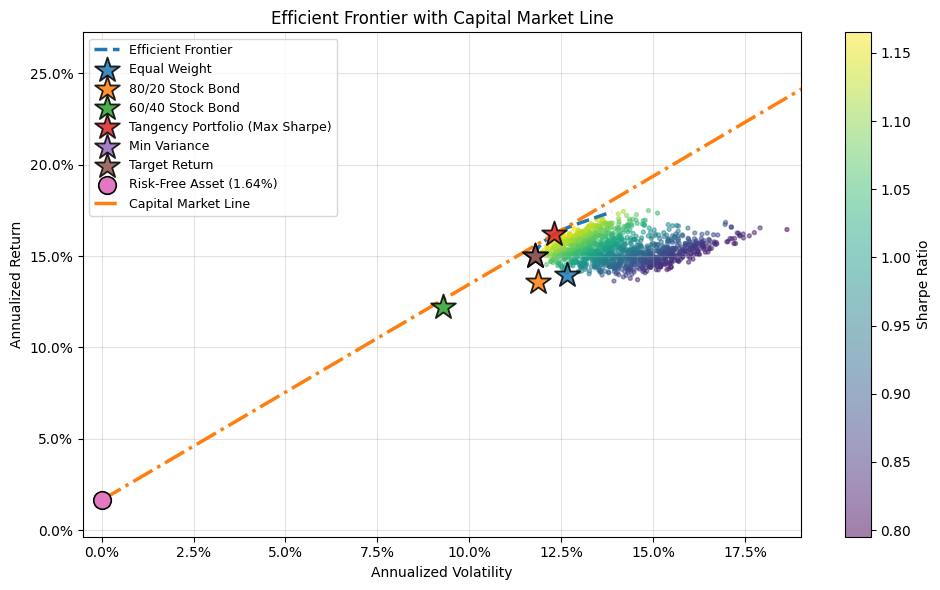

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

# Candidate portfolios
sc = ax.scatter(
    candidate_metrics["volatility"],
    candidate_metrics["return"],
    c=candidate_metrics["sharpe"],
    s=8,
    alpha=0.5,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Sharpe Ratio")

# Efficient frontier
if frontier is not None and not frontier.empty:
    ax.plot(
        frontier["volatility"],
        frontier["return"],
        linestyle="--",
        linewidth=2.5,
        label="Efficient Frontier",
    )

# Highlighted portfolios
highlighted = results["highlighted"]

for name, (vol, ret) in highlighted.items():
    label = "Tangency Portfolio (Max Sharpe)" if name == "Max Sharpe" else name

    ax.scatter(
        vol,
        ret,
        marker="*",
        s=350,
        edgecolors="black",
        linewidths=1.3,
        label=label,
        zorder=10,
        alpha=0.85,
    )

# Risk-free asset
ax.scatter(
    0,
    rf,
    marker="o",
    s=160,
    edgecolors="black",
    linewidths=1.2,
    label=f"Risk-Free Asset ({rf:.2%})",
    zorder=12,
)

# Capital Market Line
ax.plot(
    cml_x,
    cml_y,
    linestyle="-.",
    linewidth=2.5,
    label="Capital Market Line",
    zorder=9,
)

ax.set_title("Efficient Frontier with Capital Market Line")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.grid(True, alpha=0.35)
ax.legend(loc="upper left", fontsize=9)

ax.set_xlim(-0.005, candidate_metrics["volatility"].max() * 1.02)
ax.set_ylim(
    min(rf - 0.02, candidate_metrics["return"].min() - 0.02),
    max(candidate_metrics["return"].max(), cml_y.max()) * 1.01,
)

plt.tight_layout()

save_or_show(
    None if FIG_DIR is None else FIG_DIR / "efficient_frontier_with_cml.png"
)


In [29]:
cml_interpretation_md = f"""
### Capital Market Line Interpretation

The Capital Market Line starts from the risk-free asset and passes through the Tangency Portfolio.

In this analysis, the Tangency Portfolio is the **Maximum Sharpe Portfolio**, with an expected return of **{tangency_return:.2%}**, volatility of **{tangency_volatility:.2%}**, and Sharpe Ratio of **{tangency_sharpe:.2f}**.

The slope of the CML is equal to the Sharpe Ratio of the Tangency Portfolio:

$$
\\text{{Slope of CML}}
=
\\frac{{R_T - R_f}}{{\\sigma_T}}
$$

where $R_T$ and $\\sigma_T$ denote the expected return and volatility of the Tangency Portfolio.

Portfolios below the CML are less efficient because they provide lower expected return for the same level of risk.

Under the classical capital market framework, investors can combine the risk-free asset with the Tangency Portfolio to choose their desired risk level.

### Practical Interpretation

The Tangency Portfolio represents the optimal risky portfolio because it maximizes the Sharpe Ratio among all feasible portfolios under the mean-variance framework.

Rather than searching for different optimal portfolios for different risk preferences, investors can simply adjust their allocation between:

- **Risk-free asset (cash or short-term Treasury bills)**
- **Tangency Portfolio (Maximum Sharpe Portfolio)**

to reach any desired point on the Capital Market Line.

Different risk preferences can be achieved by changing the mix between the two assets:

- Holding **more cash** moves the portfolio toward the risk-free asset, reducing both expected return and volatility.
- Investing **100% in the Tangency Portfolio** achieves the highest risk-adjusted return (maximum Sharpe Ratio).
- Using **leverage (borrowing at the risk-free rate)** moves the portfolio beyond the Tangency Portfolio, increasing both expected return and volatility.

Therefore, according to Capital Market Theory, every point on the Capital Market Line represents an efficient portfolio constructed from a combination of the risk-free asset and the Tangency Portfolio.

"""

display(Markdown(cml_interpretation_md))


### Capital Market Line Interpretation

The Capital Market Line starts from the risk-free asset and passes through the Tangency Portfolio.

In this analysis, the Tangency Portfolio is the **Maximum Sharpe Portfolio**, with an expected return of **16.18%**, volatility of **12.30%**, and Sharpe Ratio of **1.18**.

The slope of the CML is equal to the Sharpe Ratio of the Tangency Portfolio:

$$
\text{Slope of CML}
=
\frac{R_T - R_f}{\sigma_T}
$$

where $R_T$ and $\sigma_T$ denote the expected return and volatility of the Tangency Portfolio.

Portfolios below the CML are less efficient because they provide lower expected return for the same level of risk.

Under the classical capital market framework, investors can combine the risk-free asset with the Tangency Portfolio to choose their desired risk level.

### Practical Interpretation

The Tangency Portfolio represents the optimal risky portfolio because it maximizes the Sharpe Ratio among all feasible portfolios under the mean-variance framework.

Rather than searching for different optimal portfolios for different risk preferences, investors can simply adjust their allocation between:

- **Risk-free asset (cash or short-term Treasury bills)**
- **Tangency Portfolio (Maximum Sharpe Portfolio)**

to reach any desired point on the Capital Market Line.

Different risk preferences can be achieved by changing the mix between the two assets:

- Holding **more cash** moves the portfolio toward the risk-free asset, reducing both expected return and volatility.
- Investing **100% in the Tangency Portfolio** achieves the highest risk-adjusted return (maximum Sharpe Ratio).
- Using **leverage (borrowing at the risk-free rate)** moves the portfolio beyond the Tangency Portfolio, increasing both expected return and volatility.

Therefore, according to Capital Market Theory, every point on the Capital Market Line represents an efficient portfolio constructed from a combination of the risk-free asset and the Tangency Portfolio.

